In [1]:

import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/file_summary.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/file_summary.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/file_summary.csv')
df3['Condition'] = 'GH Starved-Starved'


df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/file_summary.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/file_summary.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/file_summary.csv')
df6['Condition'] = 'SI Starved-Starved'


summary_df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)

# files where both larvae/tracks are present at end
valid_files = (
    summary_df
    .groupby(['Condition', 'video_name'])['present_at_end']
    .all()
    .reset_index()
)

valid_files = valid_files[valid_files['present_at_end'] == True]

valid_files['file'] = valid_files['video_name'] + '.tracks.feather'

valid_files


,Condition,video_name,present_at_end,file
1,GH Fed-Fed,2026-04-28_12-20-56_td13,True,2026-04-28_12-20-56_td13.tracks.feather
2,GH Fed-Fed,2026-04-28_15-17-04_td10,True,2026-04-28_15-17-04_td10.tracks.feather
4,GH Fed-Fed,2026-04-28_15-20-06_td12,True,2026-04-28_15-20-06_td12.tracks.feather
5,GH Fed-Fed,2026-05-11_11-25-39_td18,True,2026-05-11_11-25-39_td18.tracks.feather
6,GH Fed-Fed,2026-05-11_11-26-49_td19,True,2026-05-11_11-26-49_td19.tracks.feather
7,GH Fed-Fed,2026-05-11_11-28-10_td20,True,2026-05-11_11-28-10_td20.tracks.feather
8,GH Fed-Fed,2026-05-12_14-50-28_td18,True,2026-05-12_14-50-28_td18.tracks.feather
10,GH Fed-Fed,2026-05-12_14-53-10_td20,True,2026-05-12_14-53-10_td20.tracks.feather
11,GH Fed-Fed,2026-05-18_12-02-50_td17,True,2026-05-18_12-02-50_td17.tracks.feather
14,GH Fed-Fed,2026-05-18_12-07-50_td20,True,2026-05-18_12-07-50_td20.tracks.feather


In [2]:


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/closest_contacts_1mm.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/closest_contacts_1mm.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/closest_contacts_1mm.csv')
df3['Condition'] = 'GH Starved-Starved'



df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/closest_contacts_1mm.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/closest_contacts_1mm.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/closest_contacts_1mm.csv')
df6['Condition'] = 'SI Starved-Starved'


contacts_df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)


# filter contacts
filtered_contacts = contacts_df.merge(
    valid_files[['Condition', 'file']],
    on=['Condition', 'file'],
    how='inner'
)

df = filtered_contacts.copy()

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_39784/1020484617.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


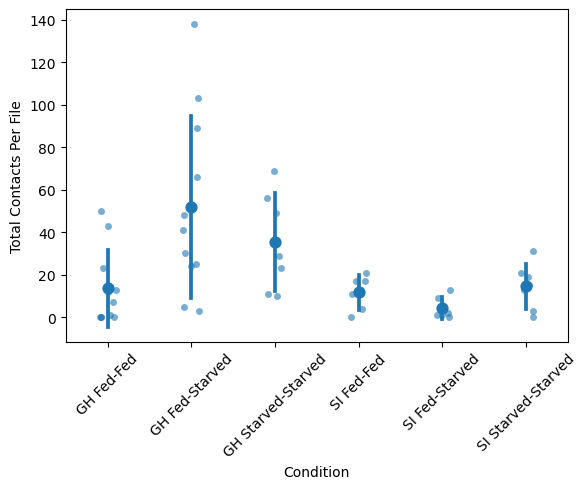

In [3]:
contacts_per_file = (
    df.groupby(['Condition', 'file'])['frame']
    .apply(lambda x: x.notna().sum())
    .reset_index(name='total_contacts')
)


plt.figure(figsize=(6,5))

sns.pointplot(
    data=contacts_per_file,
    x='Condition',
    y='total_contacts',
    errorbar='sd',
    join=False
)

sns.stripplot(
    data=contacts_per_file,
    x='Condition',
    y='total_contacts',
    alpha=0.6
)

plt.xticks(rotation=45)
plt.ylabel('Total Contacts Per File')
plt.xlabel('Condition')

plt.tight_layout()
plt.show()

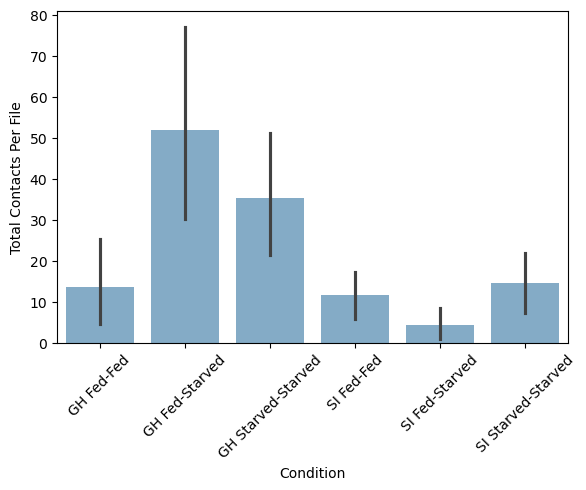

In [4]:
contacts_per_file = (
    df.groupby(['Condition', 'file'])['frame']
    .apply(lambda x: x.notna().sum())
    .reset_index(name='total_contacts')
)


plt.figure(figsize=(6,5))


sns.barplot(
    data=contacts_per_file,
    x='Condition',
    y='total_contacts',
    alpha=0.6
)

plt.xticks(rotation=45)
plt.ylabel('Total Contacts Per File')
plt.xlabel('Condition')

plt.tight_layout()
plt.show()